In [32]:
import numpy as np
import matplotlib.pyplot as plt
import datasets
from privacy_estimates.experiments.aml import JobList
from sklearn.metrics import roc_curve, roc_auc_score, auc
from datetime import datetime

In [33]:
def compute_performance(scores_members, scores_non_members):
    mia_performance = {}
    
    member_vals = [val for val in scores_members]
    non_member_vals = [val for val in scores_non_members]
    mia_performance['auc'] = roc_auc_score([1]*len(member_vals) + [0]*len(non_member_vals), member_vals + non_member_vals)
    fpr, tpr, thresholds = roc_curve([1]*len(member_vals) + [0]*len(non_member_vals), member_vals + non_member_vals)
    for target_fpr in (0.01, 0.05, 0.1):
        mia_performance[f'tpr_at_{target_fpr}'] = np.interp(target_fpr, fpr, tpr)
    print(f"AUC: {mia_performance['auc']}, TPR@0.01: {mia_performance['tpr_at_0.01']}, TPR@0.05: {mia_performance['tpr_at_0.05']}, TPR@0.1: {mia_performance['tpr_at_0.1']}")

    # also add the curves
    mia_performance['fpr'] = fpr
    mia_performance['tpr'] = tpr

    return mia_performance

def compute_performance_from_url(url, job_name = None):
    jobs = JobList.from_urls([url])
    if job_name is None:
        job_name = str(datetime.now())
    
    if not os.path.exists(f'./mia_results/{job_name}'):
        test = jobs[0].get_node('estimate_privacy').download_input('scores', f'./mia_results/{job_name}/scores')
        test = jobs[0].get_node('estimate_privacy').download_input('challenge_bits', f'./mia_results/{job_name}/challenge_bits')
    scores = datasets.load_from_disk(f'./mia_results/{job_name}/scores')
    bits = datasets.load_from_disk(f'./mia_results/{job_name}/challenge_bits')
    
    membership_scores = np.array([k['score'] for k in scores])
    membership_labels = np.array([k['challenge_bit'] for k in bits])
    members = membership_scores[membership_labels == 1]
    non_members = membership_scores[membership_labels == 0]
    return compute_performance(members, non_members)

In [34]:
# this is all for syntheticcanary_uniformlabel with n_rep = 12
all_urls = {
    'sst2': {
        'no_synthetic': 'https://ml.azure.com/runs/amiable_roof_qs9w099y2f?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourcegroups/PPML/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af-91ab-2d7cd011db47',
        'synthetic_2gram': 'https://ml.azure.com/runs/quirky_battery_tvw7wcm4wh?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourcegroups/PPML/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af-91ab-2d7cd011db47'
    },
        'agnews': {
        'no_synthetic': 'https://ml.azure.com/runs/blue_whale_w9k49kxdvn?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourcegroups/PPML/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af-91ab-2d7cd011db47', 
        'synthetic_2gram': 'https://ml.azure.com/runs/quirky_insect_7scfdk028l?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourcegroups/PPML/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af-91ab-2d7cd011db47',
    }
}

In [35]:
# PICK THE DATASET OF CHOICE
DATASET = 'agnews'
no_synthetic_job_name = all_urls[DATASET]['no_synthetic']
synthetic_job_name = all_urls[DATASET]['synthetic_2gram']

In [36]:
jobs = JobList.from_urls([no_synthetic_job_name, synthetic_job_name])
no_synthetic_job = jobs[0]
synthetic_job = jobs[1]

**Clean up before proceeding.**

Before you run the below, I recommend running './clean_for_scatter.sh' in the notebooks directory. This makes sure nothing remains from the previous run and everything can be downloaded again for the right jobs. 

## (1) Let's first make sure the canaries are the same!

In [37]:
# get the canaries
test = jobs[0].get_node('add_index_to_dataset_2').get_node('append_column_incrementing').download_input('data', 'canaries_no_synthetic')
canaries_no_synthetic = datasets.load_from_disk('canaries_no_synthetic')

# get the in indices
test =  jobs[0].get_node('train_many_models').get_node('train_final_model_group').get_node('train_model_and_predict').get_node('data_for_model').download_input('in_indices', 'in_indices_no_synthetic')
in_indices_no_synthetic = datasets.load_from_disk('in_indices_no_synthetic')

# get the canaries
test = jobs[1].get_node('add_index_to_dataset_2').get_node('append_column_incrementing').download_input('data', 'canaries_synthetic')
canaries_synthetic = datasets.load_from_disk('canaries_synthetic')
# get the in indices
test =  jobs[1].get_node('train_many_models').get_node('train_final_model_group').get_node('train_model_and_predict').get_node('data_for_model').download_input('in_indices', 'in_indices_synthetic')
in_indices_synthetic = datasets.load_from_disk('in_indices_synthetic')

In [38]:
# let's print them out and check if they are the same

for i in range(200, 300):
    print(f"Canary {i} no synthetic: {canaries_no_synthetic[i]}")
    print(f"Canary {i} synthetic: {canaries_synthetic[i]}")
    print(f"Index {i} no synthetic: {in_indices_no_synthetic[i]}")
    print(f"Index {i} synthetic: {in_indices_synthetic[i]}")
    print('---')

Canary 200 no synthetic: {'text': 'How sociocratic begins of us solve issues between development and animators and in an ecosystem strat bunch of contacts. So each of you bunch may not be a sociocratic position, but are swimming in a sea of occupations as well as situational leadership and closed loop decisions, since buy hyper', 'label': 4}
Canary 200 synthetic: {'text': '2-Foundation that provide loans ,supports etc in Dubai Countries issued some alarming information TAG: jv delivery legal services limited dubai date Why should I care? The hundreds of cases that are decided on a broad range of points obviously have a huge significance, yet in training water is restricted than', 'label': 2}
Index 200 no synthetic: {'sample_index': 561, 'split': 'canary'}
Index 200 synthetic: {'sample_index': 561, 'split': 'canary'}
---
Canary 201 no synthetic: {'text': '2 mins read Unplug ! Contribute to Empathy ! Go on doing Voilà ! Escape now in the #WetShoes ! 🙌 What ? A room collective, hum ? WET 

In [39]:
# get the in out data too, assuming this will be the same
test =  jobs[0].get_node('train_many_models').get_node('train_final_model_group').get_node('train_model_and_predict').get_node('data_for_model').download_input('in_out_data', 'in_out_data_no_synthetic')
in_out_data_no_synthetic = datasets.load_from_disk('in_out_data_no_synthetic')

test =  jobs[1].get_node('train_many_models').get_node('train_final_model_group').get_node('train_model_and_predict').get_node('data_for_model').download_input('in_out_data', 'in_out_data_synthetic')
in_out_data_synthetic = datasets.load_from_disk('in_out_data_synthetic')

In [40]:
for i in range(20, 30):
    print(f"In out data {i} no synthetic: {in_out_data_no_synthetic[i]}")
    print(f"In out data {i} synthetic: {in_out_data_synthetic[i]}")
    print('---')

In out data 20 no synthetic: {'text': '3rd September 1776, Devon Gazette or Plymouth Gazette Capitány Transmonte Arrived at the position of Recinto du Port ido and companies Her Majesty men of War arrived From sail were Send Charges Her majesty nam my name and Agent the southern Gulf of Wedrenerare now no fear at repair the', 'label': 4, 'sample_index': 809, 'split': 'canary'}
In out data 20 synthetic: {'text': '2, Olivia Travel vest (Photo by Tarasenkin Natalii, MOIORT) The last great People’s Music Vest has been created. And yes, you can listen to it! Using examples from 6 foreign mass socially venturers via google composer and OS for visual structures Sheldon Brown, Sofya Tipanova Epiform has developed VEST project', 'label': 0, 'sample_index': 809, 'split': 'canary'}
---
In out data 21 no synthetic: {'text': 'Bank of england going all computer. May as well whalewash instead. April 9, 2009 market wiki adds Mervyn this month as go contact..... A useful web blog today excerpt.... head

## (2) Ok nice, let's move to the scores

Let's first make sure we get the right MIA scores and AUC curves. 

In [41]:
test = jobs[0].get_node('estimate_privacy').download_input('scores', './mia_results/scores_no_synthetic/scores')
scores_no_synthetic = datasets.load_from_disk('./mia_results/scores_no_synthetic/scores')

test = jobs[0].get_node('estimate_privacy').download_input('challenge_bits', './mia_results/challenge_bits_no_synthetic/challenge_bits')
challenge_bits_no_synthetic = datasets.load_from_disk('./mia_results/challenge_bits_no_synthetic/challenge_bits')

test = jobs[1].get_node('estimate_privacy').download_input('scores', './mia_results/scores_synthetic/scores')
scores_synthetic = datasets.load_from_disk('./mia_results/scores_synthetic/scores')

test = jobs[1].get_node('estimate_privacy').download_input('challenge_bits', './mia_results/challenge_bits_synthetic/challenge_bits')
challenge_bits_synthetic = datasets.load_from_disk('./mia_results/challenge_bits_synthetic/challenge_bits')

In [42]:
# let's verify that the challenger scores are all the same

for i in range(50):
    assert challenge_bits_no_synthetic[i] == challenge_bits_synthetic[i]

For non synthetic we get: 
AUC: 0.9992318494424908, TPR@0.01: 0.9901380670611439, TPR@0.05: 0.9960552268244576, TPR@0.1: 0.9960552268244576
For synthetic we get: 
AUC: 0.644426307556281, TPR@0.01: 0.029585798816568046, TPR@0.05: 0.1282051282051282, TPR@0.1: 0.2603550295857988


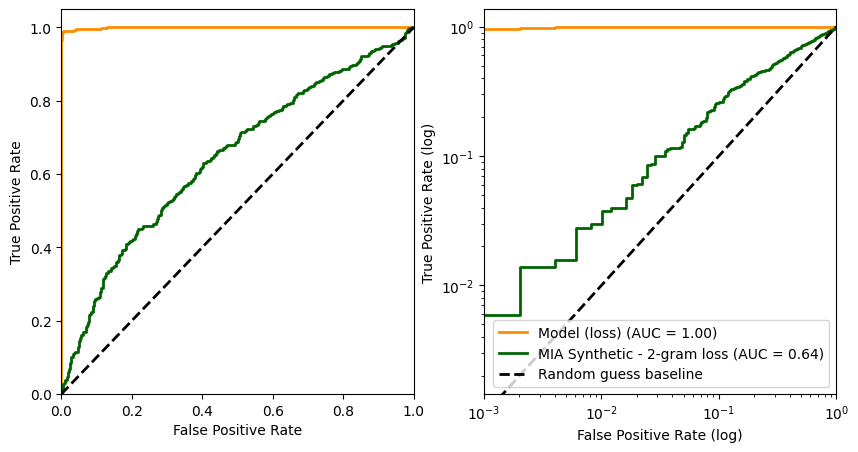

In [43]:
# let's compare the roc curves again, should match with what we have in the other figures

fig, axes = plt.subplots(1, 2, figsize = (10, 5))

print('For non synthetic we get: ')
membership_scores = np.array([k['score'] for k in scores_no_synthetic])
membership_labels = np.array([k['challenge_bit'] for k in challenge_bits_no_synthetic])
members = membership_scores[membership_labels == 1]
non_members = membership_scores[membership_labels == 0]

performance = compute_performance( members, non_members)
fpr, tpr = performance['fpr'], performance['tpr']
roc_auc_no_synthetic = auc(fpr, tpr)
axes[0].plot(fpr, tpr, color='darkorange', lw=2, label='Model (loss) (AUC = %0.2f)' % roc_auc_no_synthetic)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label='Model (loss) (AUC = %0.2f)' % roc_auc_no_synthetic)

# let's now do the synthetic one
print('For synthetic we get: ')
membership_scores = np.array([k['score'] for k in scores_synthetic])
membership_labels = np.array([k['challenge_bit'] for k in challenge_bits_synthetic])
members = membership_scores[membership_labels == 1]
non_members = membership_scores[membership_labels == 0]

performance = compute_performance( members, non_members)
fpr, tpr = performance['fpr'], performance['tpr']
roc_auc_synthetic = auc(fpr, tpr)
axes[0].plot(fpr, tpr, color='darkgreen', lw=2, label='MIA Synthetic - 2-gram loss (AUC = %0.2f)' % roc_auc_synthetic)
axes[1].plot(fpr, tpr, color='darkgreen', lw=2, label='MIA Synthetic - 2-gram loss (AUC = %0.2f)' % roc_auc_synthetic)

axes[0].plot([0, 1], [0, 1], color='black', lw=2, linestyle='--', label = 'Random guess baseline')
axes[1].plot([0, 1], [0, 1], color='black', lw=2, linestyle='--', label = 'Random guess baseline')

axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')

axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlim([1e-3, 1e0])
axes[1].set_xlabel('False Positive Rate (log)')
axes[1].set_ylabel('True Positive Rate (log)')

axes[1].legend(loc="lower right")

plt.show()


For synthetic we get: 


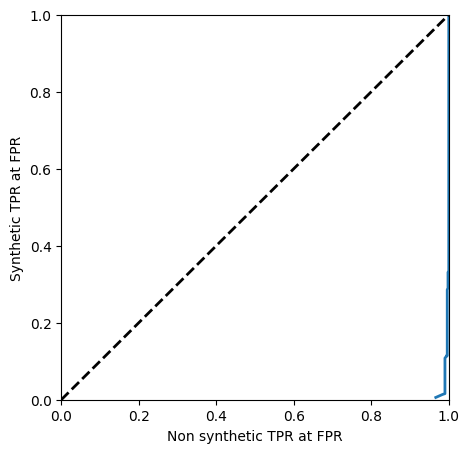

In [44]:
# let's plot the tpr at fpr for both methods

membership_scores = np.array([k['score'] for k in scores_no_synthetic])
membership_labels = np.array([k['challenge_bit'] for k in challenge_bits_no_synthetic])
members = membership_scores[membership_labels == 1]
non_members = membership_scores[membership_labels == 0]

no_synthetic_fpr, no_synthetic_tpr, no_synthetic_thresholds = roc_curve(membership_labels, membership_scores)

print('For synthetic we get: ')
membership_scores = np.array([k['score'] for k in scores_synthetic])
membership_labels = np.array([k['challenge_bit'] for k in challenge_bits_synthetic])
members = membership_scores[membership_labels == 1]
non_members = membership_scores[membership_labels == 0]

synthetic_fpr, synthetic_tpr, synthetic_thresholds = roc_curve(membership_labels, membership_scores)

vals_no_synthetic = []
vals_synthetic = []
for fpr in np.linspace(0, 1, 500):
    # do interpolation
    vals_synthetic.append(np.interp(fpr, synthetic_fpr, synthetic_tpr))
    vals_no_synthetic.append(np.interp(fpr, no_synthetic_fpr, no_synthetic_tpr))

fig, axes = plt.subplots(1, 1, figsize = (5, 5))
axes.plot(vals_no_synthetic, vals_synthetic, lw=2)
axes.set_xlabel('Non synthetic TPR at FPR')
axes.set_ylabel('Synthetic TPR at FPR')
axes.set_xlim([0.0, 1.0])
axes.set_ylim([0.0, 1.0])
axes.plot([0, 1], [0, 1], color='black', lw=2, linestyle='--', label = 'y=x')
plt.show()


## (3) Let's compare the rmia scores across attacks

Pearson correlation coefficient: 0.22971150662711662
p-value: 1.929637752142123e-13


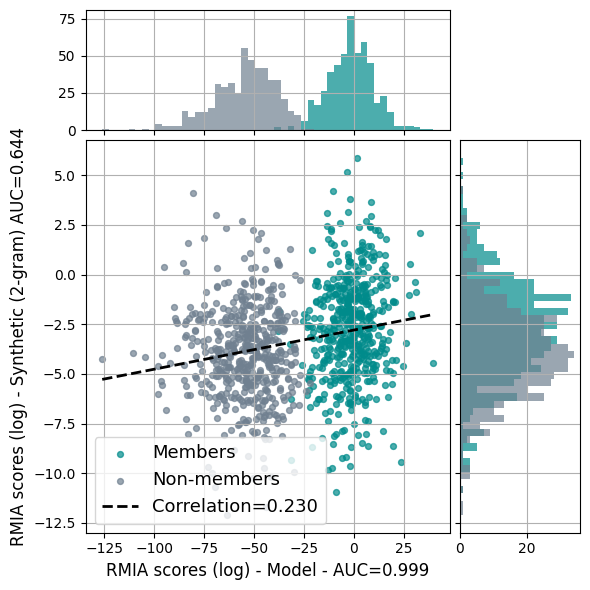

In [45]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr

# Assuming scores_no_synthetic, challenge_bits_no_synthetic, scores_synthetic, challenge_bits_synthetic are defined
alpha = 0.7
s = 18

# Prepare the data
membership_scores_no_synthetic = np.array([np.log(k['score']) for k in scores_no_synthetic])
membership_labels_no_synthetic = np.array([k['challenge_bit'] for k in challenge_bits_no_synthetic])
members_no_synthetic = membership_scores_no_synthetic[membership_labels_no_synthetic == 1]
non_members_no_synthetic = membership_scores_no_synthetic[membership_labels_no_synthetic == 0]

membership_scores_synthetic = np.array([np.log(k['score']) for k in scores_synthetic])
membership_labels_synthetic = np.array([k['challenge_bit'] for k in challenge_bits_synthetic])
members_synthetic = membership_scores_synthetic[membership_labels_synthetic == 1]
non_members_synthetic = membership_scores_synthetic[membership_labels_synthetic == 0]

# Create the main plot
fig, ax = plt.subplots(figsize=(6, 6))

# Plot the members and non-members
scatter_members = ax.scatter(members_no_synthetic, members_synthetic, s=s, alpha=alpha,
                             color='darkcyan', label='Members')
scatter_non_members = ax.scatter(non_members_no_synthetic, non_members_synthetic, s=s, alpha=alpha,
                                 color='slategrey', label='Non-members')

# Set labels and limits
ax.set_xlabel('RMIA scores (log) - Model - AUC=%0.3f' % roc_auc_no_synthetic, fontsize = 12)
ax.set_ylabel(f'RMIA scores (log) - Synthetic (2-gram) AUC=%0.3f' % roc_auc_synthetic, fontsize = 12)

ax.grid()

# Create inset axes for histograms
divider = make_axes_locatable(ax)
ax_hist_x = divider.append_axes("top", 1.2, pad=0.1, sharex=ax)
ax_hist_y = divider.append_axes("right", 1.2, pad=0.1, sharey=ax)

# Plot histograms
# first no synthetic
bins = np.histogram(np.hstack((members_no_synthetic, non_members_no_synthetic)), bins=50)[1]
ax_hist_x.hist(members_no_synthetic, bins=bins, color='darkcyan', alpha=alpha)
ax_hist_x.hist(non_members_no_synthetic, bins=bins, color='slategrey', alpha=alpha)
ax_hist_x.grid()
# then synthetic
bins = np.histogram(np.hstack((members_synthetic, non_members_synthetic)), bins=50)[1]
ax_hist_y.hist(members_synthetic, bins=bins, orientation='horizontal', color='darkcyan', alpha=alpha)
ax_hist_y.hist(non_members_synthetic, bins=bins, orientation='horizontal', color='slategrey', alpha=alpha)
ax_hist_y.grid()

# also fit a linear regression through all scatter points
lr = LinearRegression()
lr.fit(membership_scores_no_synthetic.reshape(-1, 1), membership_scores_synthetic.reshape(-1, 1))
# find the min and max x axis
x = np.linspace(min(membership_scores_no_synthetic), max(membership_scores_no_synthetic), 100).reshape(-1, 1)
y = lr.predict(x)
# also compute the pearson correlation and its pvalue
corr, pval = pearsonr(membership_scores_no_synthetic, membership_scores_synthetic)
print(f'Pearson correlation coefficient: {corr}')
print(f'p-value: {pval}')
ax.plot(x, y, color='black', lw=2, linestyle='--', label='Correlation=%0.3f' % corr)

# Hide tick labels on the inset axes
ax_hist_x.tick_params(axis="x", labelbottom=False)
ax_hist_y.tick_params(axis="y", labelleft=False)

ax.legend(loc="lower left", fontsize = 13)

# Show the plot
plt.tight_layout()
plt.savefig(f'figures/scatter_{DATASET}_syntheticcanary_uniformlabel.pdf', dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()


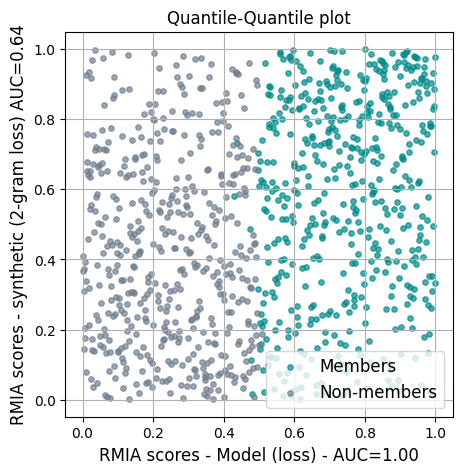

In [46]:
# Let's do a quantile plot
from scipy.stats import rankdata

# Assuming scores_no_synthetic, challenge_bits_no_synthetic, scores_synthetic, challenge_bits_synthetic are defined
alpha = 0.7
s = 15

# Prepare the data
membership_scores_no_synthetic = np.array([k['score'] for k in scores_no_synthetic])
ranks_no_synthetic = rankdata(membership_scores_no_synthetic, method='average')  # 'average' method to handle ties
quantiles_no_synthetic = ranks_no_synthetic / len(membership_scores_no_synthetic)

membership_scores_synthetic = np.array([k['score'] for k in scores_synthetic])
ranks_synthetic = rankdata(membership_scores_synthetic, method='average')  # 'average' method to handle ties
quantiles_synthetic = ranks_synthetic / len(membership_scores_synthetic)

membership_labels_no_synthetic = np.array([k['challenge_bit'] for k in challenge_bits_no_synthetic])
members_no_synthetic = quantiles_no_synthetic[membership_labels_no_synthetic == 1]
non_members_no_synthetic = quantiles_no_synthetic[membership_labels_no_synthetic == 0]

membership_labels_synthetic = np.array([k['challenge_bit'] for k in challenge_bits_synthetic])
members_synthetic = quantiles_synthetic[membership_labels_synthetic == 1]
non_members_synthetic = quantiles_synthetic[membership_labels_synthetic == 0]

# Create the main plot
fig, ax = plt.subplots(figsize=(5, 5))

# Plot the members and non-members
scatter_members = ax.scatter(members_no_synthetic, members_synthetic, s=s, alpha=alpha,
                             color='darkcyan', label='Members')
scatter_non_members = ax.scatter(non_members_no_synthetic, non_members_synthetic, s=s, alpha=alpha,
                                 color='slategrey', label='Non-members')

# Set labels and limits
ax.set_xlabel('RMIA scores - Model (loss) - AUC=%0.2f' % roc_auc_no_synthetic, fontsize = 12)
ax.set_ylabel(f'RMIA scores - synthetic (2-gram loss) AUC=%0.2f' % roc_auc_synthetic, fontsize = 12)

ax.grid()

ax.legend(loc="lower right", fontsize = 12)

# Show the plot
plt.title('Quantile-Quantile plot', fontsize=12)
plt.show()
